
# KFCA Technical Test - Accident vs Non-Accident Image Classification

## Objective
This notebook builds a binary image classifier to distinguish between **Accident** and **Non Accident** images using transfer learning with **ResNet18**.

## Approach Summary
- Load image data from Google Drive
- Apply preprocessing and augmentation
- Create a stratified train/validation split
- Fine-tune a pretrained ResNet18 model
- Evaluate performance on validation and test sets
- Export test predictions to CSV

## Why this approach
I used transfer learning because the dataset is relatively small, and a pretrained model can learn robust image features faster and more reliably than training from scratch.

## Structure of the notebook
The notebook is structured in the same order as a typical ML workflow:
1. Setup and configuration
2. Data loading and exploration
3. Data preprocessing
4. Model definition
5. Training
6. Evaluation
7. Test inference and export



-------
# 1. Environment Setup, Configuration, and Image Transforms


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ======================
# 1. Imports
# ======================
import os
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# ======================
# 2. Config
# ======================
class CFG:
    data_dir = "/content/drive/MyDrive/dataset"
    train_dir = os.path.join(data_dir, "train")
    test_dir = os.path.join(data_dir, "test")

    img_size = 224
    batch_size = 32
    lr = 1e-4
    valid_size = 0.2
    num_workers = 2
    epochs = 50
    early_stopping_patience = 7
    seed = 42

    device = "cuda" if torch.cuda.is_available() else "cpu"


# ======================
# 3. Seed for reproducibility
# ======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)
print("Using device:", CFG.device)


# ======================
# 4. Transforms
# ======================
train_transform = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])




Mounted at /content/drive
Using device: cuda


# 2. Dataset Loading, Class Distribution, and Train/Validation Split

In [3]:
# ======================
# 5. Dataset Loading + EDA
# ======================
base_dataset = ImageFolder(root=CFG.train_dir)

class_names = base_dataset.classes
num_classes = len(class_names)
targets = [label for _, label in base_dataset.samples]

print("------------------------------------------------------------------------")
print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total training images:", len(base_dataset))

class_counts = Counter(targets)
eda_df = pd.DataFrame({
    "class_name": [class_names[i] for i in range(num_classes)],
    "class_index": list(range(num_classes)),
    "image_count": [class_counts[i] for i in range(num_classes)]
})

print("------------------------------------------------------------------------")
print("\nClass distribution:")
display(eda_df)


# ======================
# 6. Stratified Train/Val Split
# ======================
all_indices = list(range(len(base_dataset)))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=CFG.valid_size,
    stratify=targets,
    random_state=CFG.seed
)
print("------------------------------------------------------------------------")
print(f"Train samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")


# ======================
# 7. Separate datasets with separate transforms
# ======================
train_dataset_full = ImageFolder(root=CFG.train_dir, transform=train_transform)
val_dataset_full = ImageFolder(root=CFG.train_dir, transform=val_test_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

test_dataset = ImageFolder(root=CFG.test_dir, transform=val_test_transform)

print("------------------------------------------------------------------------")
print("Train transform applied.")
print("Validation/Test transform applied.")

------------------------------------------------------------------------
Classes: ['Accident', 'Non Accident']
Number of classes: 2
Total training images: 793
------------------------------------------------------------------------

Class distribution:


,class_name,class_index,image_count
0,Accident,0,371
1,Non Accident,1,422


------------------------------------------------------------------------
Train samples: 634
Validation samples: 159
------------------------------------------------------------------------
Train transform applied.
Validation/Test transform applied.


The dataset is reasonably balanced, so standard accuracy and weighted F1 are both meaningful evaluation metrics.

---
# 3. Visual Sanity Check of Training Samples

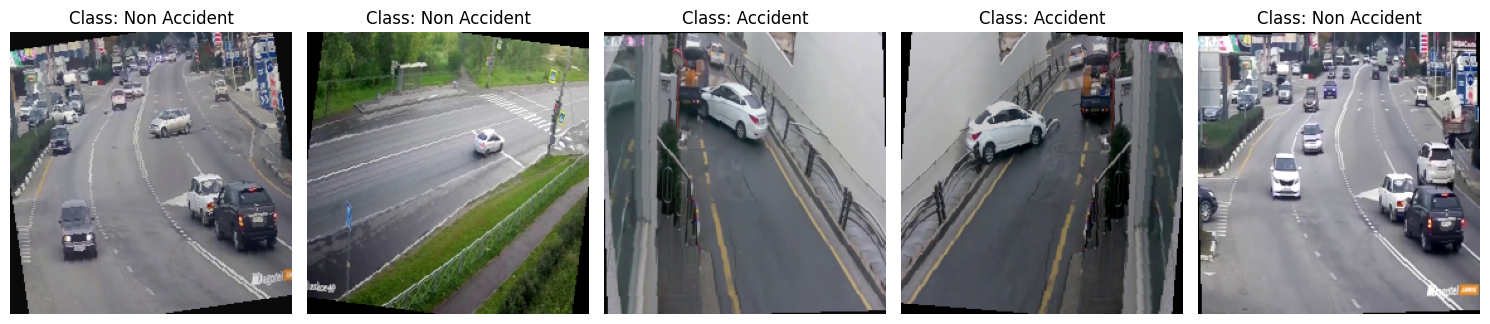

In [4]:
# ======================
# 8. Visualize Sample Training Images
# ======================

# ImageNet normalization used in ResNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Randomly select 5 samples from train set
sample_indices = random.sample(range(len(train_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, idx in enumerate(sample_indices):
    img, label = train_dataset[idx]

    # Convert CHW tensor to HWC numpy
    img_np = img.cpu().numpy().transpose(1, 2, 0)

    # Denormalize for display
    img_np = img_np * std.reshape(1, 1, 3) + mean.reshape(1, 1, 3)
    img_np = np.clip(img_np, 0, 1)

    axes[i].imshow(img_np)
    axes[i].set_title(f"Class: {class_names[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# 4. Model Architecture and Transfer Learning Strategy

This cell defines the classification model using **pretrained ResNet18**.

### Transfer learning strategy
- Start from ImageNet-pretrained weights
- Freeze most backbone layers to preserve general visual features
- Unfreeze only the final residual block (`layer4`) so the model can adapt to this task
- Replace the final fully connected layer with a custom classifier for binary prediction

### Why this approach was chosen
Because the dataset is limited in size, transfer learning is more efficient and less prone to overfitting than training a CNN from scratch.


In [5]:
# ======================
# 9. Model Setup with Transfer Learning
# ======================

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final classification layer
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

# Move model to device
model = model.to(CFG.device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# 5. Model Training, Validation, and Checkpointing

This cell contains the full training pipeline.

### Training setup
- **Loss**: CrossEntropyLoss for multi-class logits (binary task with 2 output classes)
- **Optimizer**: Adam on trainable parameters only
- **Scheduler**: ReduceLROnPlateau to lower the learning rate when validation loss stops improving
- **Early stopping**: stops training when validation F1 does not improve for several epochs


In [6]:
# ======================
# 10. Training Loop
# ======================

import copy

pin_memory = CFG.device == "cuda"

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=pin_memory
)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG.lr
)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # monitor validation loss
    patience=3,
    factor=0.5
)

# History for plots
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}


# ======================
# Training function
# ======================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return running_loss / len(loader), acc


# ======================
# Validation function
# ======================
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(CFG.device)
            labels = labels.to(CFG.device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return running_loss / len(loader), acc, f1


# ======================
# Training loop
# ======================
best_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

for epoch in range(CFG.epochs):
    print(f"\nEpoch {epoch+1}/{CFG.epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion)

    # Step scheduler AFTER validation
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    print(f"Current LR: {current_lr:.6f}")

    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_model.pth")
        epochs_without_improvement = 0
        print("Best model saved!")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

    # Early stopping
    if epochs_without_improvement >= CFG.early_stopping_patience:
        print("Early stopping triggered!")
        break


# ======================
# Load best model
# ======================
model.load_state_dict(best_model_wts)
print(f"\nBest Val F1: {best_f1:.4f}")


Epoch 1/50


Train Loss: 0.6301 | Train Acc: 0.6278
Val Loss: 0.5404 | Val Acc: 0.7547 | Val F1: 0.7529
Current LR: 0.000100
Best model saved!

Epoch 2/50


Train Loss: 0.4239 | Train Acc: 0.8091
Val Loss: 0.4215 | Val Acc: 0.7987 | Val F1: 0.7975
Current LR: 0.000100
Best model saved!

Epoch 3/50


Train Loss: 0.3297 | Train Acc: 0.8612
Val Loss: 0.3629 | Val Acc: 0.8302 | Val F1: 0.8296
Current LR: 0.000100
Best model saved!

Epoch 4/50


Train Loss: 0.2673 | Train Acc: 0.8912
Val Loss: 0.3457 | Val Acc: 0.8365 | Val F1: 0.8358
Current LR: 0.000100
Best model saved!

Epoch 5/50


...

Train Loss: 0.0896 | Train Acc: 0.9685
Val Loss: 0.2015 | Val Acc: 0.8994 | Val F1: 0.8988
Current LR: 0.000050
No improvement for 3 epoch(s)

Epoch 15/50


Train Loss: 0.0896 | Train Acc: 0.9574
Val Loss: 0.1764 | Val Acc: 0.9119 | Val F1: 0.9117
Current LR: 0.000050
No improvement for 4 epoch(s)

Epoch 16/50


Train Loss: 0.0684 | Train Acc: 0.9779
Val Loss: 0.1934 | Val Acc: 0.9119 | Val F1: 0.9116
Current LR: 0.000050
No improvement for 5 epoch(s)

Epoch 17/50


Train Loss: 0.0749 | Train Acc: 0.9748
Val Loss: 0.1920 | Val Acc: 0.9057 | Val F1: 0.9054
Current LR: 0.000050
No improvement for 6 epoch(s)

Epoch 18/50


Train Loss: 0.0845 | Train Acc: 0.9669
Val Loss: 0.1755 | Val Acc: 0.9119 | Val F1: 0.9116
Current LR: 0.000050
No improvement for 7 epoch(s)
Early stopping triggered!

Best Val F1: 0.9117


### Training outcome
At the end of training, the notebook restores the best-performing model checkpoint rather than the final epoch weights.  
This ensures all later evaluation uses the strongest validation model.

---
# 6. Validation Performance Analysis

This cell evaluates the best saved model on the validation set.

### Metrics reported
- Accuracy
- Precision
- Recall
- Weighted F1-score
- Class-wise classification report
- Confusion matrix


--------------------------------------------------
Accuracy : 0.9119
Precision: 0.9127
Recall   : 0.9119
F1 Score : 0.9117

--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

    Accident       0.93      0.88      0.90        74
Non Accident       0.90      0.94      0.92        85

    accuracy                           0.91       159
   macro avg       0.91      0.91      0.91       159
weighted avg       0.91      0.91      0.91       159


--------------------------------------------------
Confusion Matrix (%):
[[87.84 12.16]
 [ 5.88 94.12]]


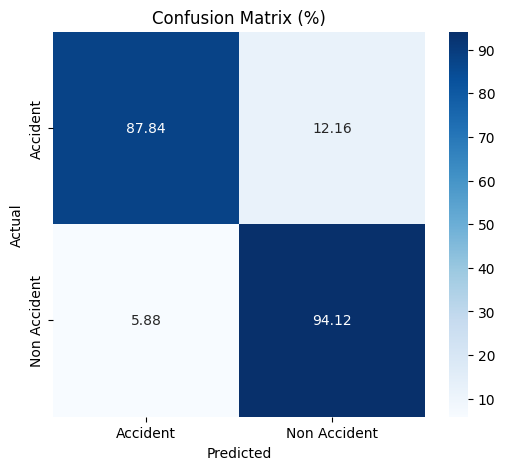

In [12]:
# ======================
# 11. Detailed Validation Metrics
# ======================

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(CFG.device)
            labels = labels.to(CFG.device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Overall Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print("\n--------------------------------------------------")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Classification Report
    print("\n--------------------------------------------------")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion Matrix as Percentage
    cm = confusion_matrix(all_labels, all_preds)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    print("\n--------------------------------------------------")
    print("Confusion Matrix (%):")
    print(np.round(cm_percent, 2))

    # Plot Confusion Matrix in Percentage
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (%)")
    plt.show()


# Load best model safely
model.load_state_dict(torch.load("best_model.pth", map_location=CFG.device))

# Evaluate
evaluate_model(model, val_loader)

# 7. Training Dynamics

This cell visualizes the learning behavior across epochs.

### What to look for
- Whether training and validation loss both decrease
- Whether validation accuracy improves consistently
- Whether there are signs of overfitting, such as widening train/validation gaps

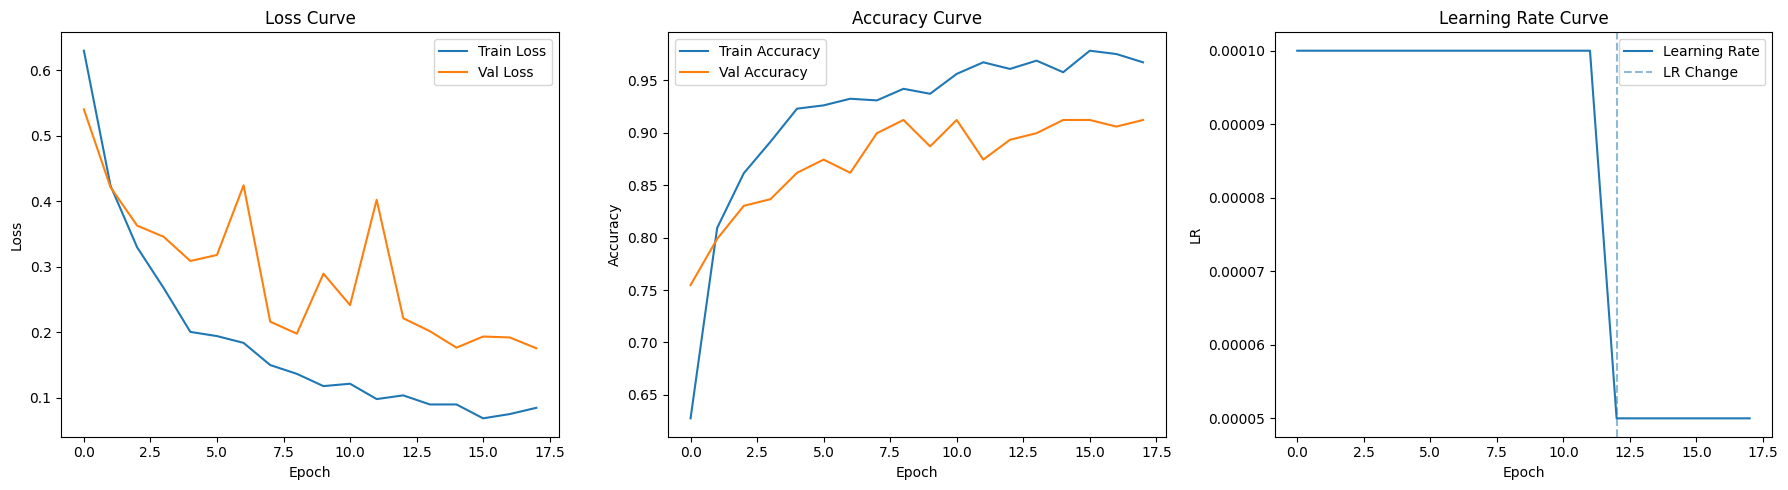

In [8]:
# ======================
# 12. Training History Plots
# ======================

plt.figure(figsize=(18, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy plot
plt.subplot(1, 3, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

# Learning rate plot
plt.subplot(1, 3, 3)
plt.plot(history["lr"], label="Learning Rate")

# Detect LR drop point automatically
for i in range(1, len(history["lr"])):
    if abs(history["lr"][i] - history["lr"][i - 1]) > 1e-12:
        plt.axvline(x=i, linestyle='--', alpha=0.5, label="LR Change")
        break

plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Curve")
plt.legend()

plt.tight_layout()
plt.show()

# 8. Test Set Inference

This cell applies the best saved model to the held-out test set.

### What is produced
For each image, the notebook stores:
- file name
- ground-truth label
- predicted label
- prediction confidence

In [9]:
# ======================
# 13. Test Inference
# ======================

# Load best saved model
model.load_state_dict(torch.load("best_model.pth", map_location=CFG.device))
model.eval()

# Class names from testing dataset
class_names = test_dataset.classes

# Store predictions
test_results = []

with torch.no_grad():
    for idx in tqdm(range(len(test_dataset))):
        image, true_label = test_dataset[idx]

        # Add batch dimension and move to device
        image = image.unsqueeze(0).to(CFG.device)

        # Forward pass
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

        # File info
        img_path = test_dataset.samples[idx][0]
        filename = os.path.basename(img_path)

        test_results.append({
            "filename": filename,
            "true_label": class_names[true_label],
            "predicted_label": class_names[pred_idx],
            "confidence": round(confidence, 4)
        })

# Convert to DataFrame
test_results_df = pd.DataFrame(test_results)

# Preview
test_results_df.head()

100%|██████████| 117/117 [00:48<00:00,  2.41it/s]


,filename,true_label,predicted_label,confidence
0,acc1 (7).jpg,Accident,Accident,0.9395
1,test10_33.jpg,Accident,Accident,1.0000
2,test10_56.jpg,Accident,Accident,0.9995
3,test10_61.jpg,Accident,Accident,0.9993
4,test12_13.jpg,Accident,Accident,0.9254


# 9. Test Set Summary Metrics

This cell summarizes final performance on the test set using a classification report.

Validation performance helps choose the model, but test performance is the final estimate of generalization.


In [10]:
print(classification_report(
    test_results_df["true_label"],
    test_results_df["predicted_label"]
))

              precision    recall  f1-score   support

    Accident       0.96      0.92      0.94        49
Non Accident       0.94      0.97      0.96        68

    accuracy                           0.95       117
   macro avg       0.95      0.94      0.95       117
weighted avg       0.95      0.95      0.95       117



# 10. Export Final Predictions

This cell saves the test predictions to a CSV file for submission.

### Output
The exported file contains one row per test image with:
- filename
- true label
- predicted label
- confidence


In [11]:
# ======================
# 14. Save Predictions to CSV
# ======================

# Save to CSV
output_path = "test_predictions.csv"
test_results_df.to_csv(output_path, index=False)

print(f"Predictions saved to {output_path}")

# Download (only for Colab)
try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    print("Download skipped (not running in Google Colab)")

Predictions saved to test_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>